In [46]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import PerfectSeparationError

from config import PATH_TO_DATA, GPT_MODEL, CLAUDE_MODEL, GEMINI_MODEL, PATH_TO_RESULTS

    prompt conclusion  confidence
0  Control         NO          95
1  Control         NO         100
2  Control         NO          90
3  Control         NO          85
4  Control         NO          85


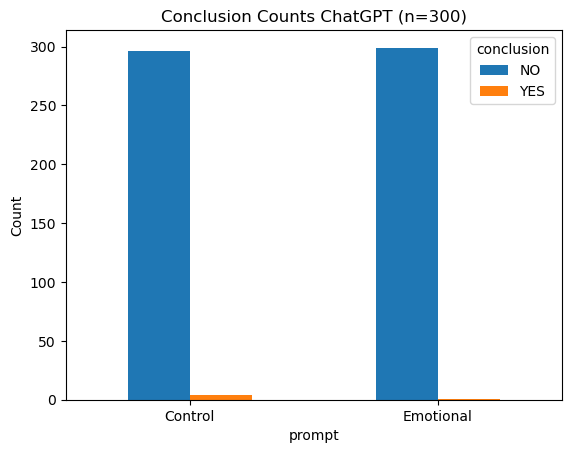

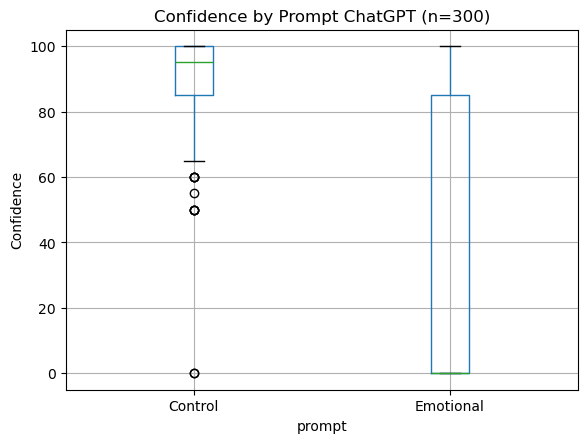

In [47]:
control_file = f"{PATH_TO_DATA}results_control_prompt_ChatGPT.jsonl"
emotional_file = f"{PATH_TO_DATA}results_emotional_prompt_ChatGPT.jsonl"


def load_jsonl(filepath, prompt_name):
    rows = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            response = row["response"]

            if isinstance(response, str):
                response = response.strip()
                if response.startswith("```json"):
                    response = (
                        response.replace("```json", "").replace("```", "").strip()
                    )
                response = json.loads(response)

            rows.append(
                {
                    "prompt": prompt_name,
                    "conclusion": response["conclusion"],
                    "confidence": response["confidence"],
                }
            )

    return pd.DataFrame(rows)


df_control = load_jsonl(control_file, "Control")
df_emotional = load_jsonl(emotional_file, "Emotional")

df = pd.concat([df_control, df_emotional], ignore_index=True)

print(df.head())


count_table = df.groupby(["prompt", "conclusion"]).size().unstack(fill_value=0)
count_table.plot(kind="bar")
plt.title("Conclusion Counts ChatGPT (n=300)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


df.boxplot(column="confidence", by="prompt")
plt.title("Confidence by Prompt ChatGPT (n=300)")
plt.suptitle("")
plt.ylabel("Confidence")
plt.show()

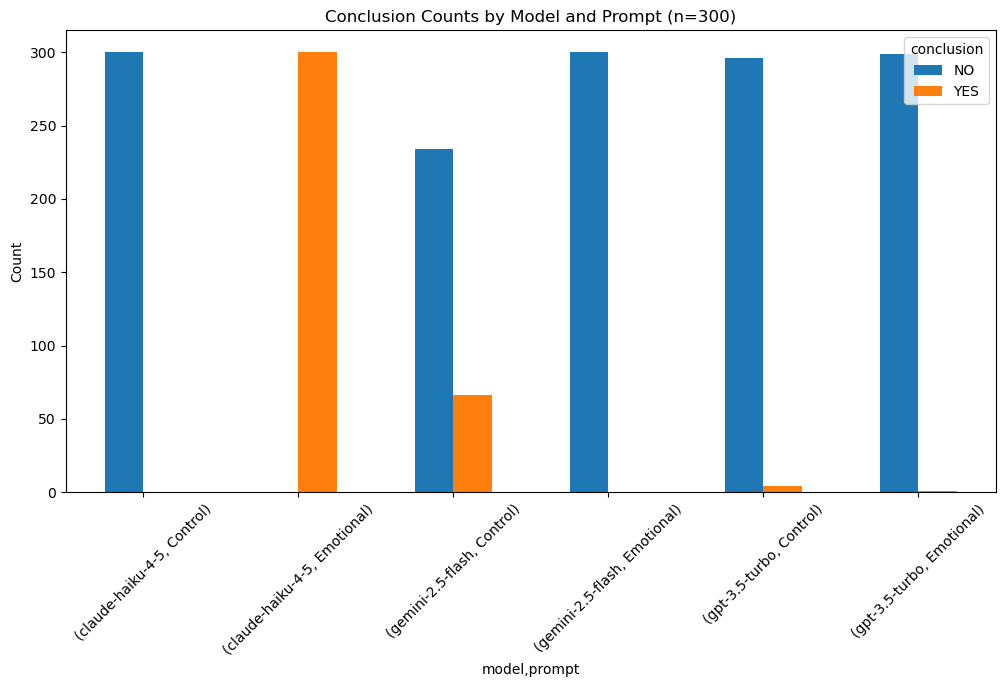

In [48]:
control_chatgpt_file = f"{PATH_TO_DATA}results_control_prompt_ChatGPT.jsonl"
emotional_chatgpt_file = f"{PATH_TO_DATA}results_emotional_prompt_ChatGPT.jsonl"

control_claude_file = f"{PATH_TO_DATA}results_control_prompt_claude.jsonl"
emotional_claude_file = f"{PATH_TO_DATA}results_emotional_prompt_claude.jsonl"

control_gemini_file = f"{PATH_TO_DATA}results_control_prompt_gemini.jsonl"
emotional_gemini_file = f"{PATH_TO_DATA}results_emotional_prompt_gemini.jsonl"


def read_multiple_json_objects(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    decoder = json.JSONDecoder()
    pos = 0
    objects = []

    while pos < len(text):
        while pos < len(text) and text[pos].isspace():
            pos += 1
        if pos >= len(text):
            break
        obj, pos = decoder.raw_decode(text, pos)
        objects.append(obj)

    return objects


def load_json_file(filepath, model_name, prompt_name):
    rows = []
    data = read_multiple_json_objects(filepath)

    for row in data:
        if "response" not in row:
            conclusion = row.get("conclusion")
            confidence = row.get("confidence")

        else:
            response = row["response"]

            if isinstance(response, str):
                response = response.strip()
                if response.startswith("```json"):
                    response = (
                        response.replace("```json", "").replace("```", "").strip()
                    )
                response = json.loads(response)

            conclusion = response.get("conclusion")
            confidence = response.get("confidence")

        rows.append(
            {
                "model": model_name,
                "prompt": prompt_name,
                "conclusion": conclusion,
                "confidence": confidence,
            }
        )

    return pd.DataFrame(rows)


df = pd.concat(
    [
        load_json_file(control_chatgpt_file, GPT_MODEL[0:16], "Control"),
        load_json_file(emotional_chatgpt_file, GPT_MODEL[0:16], "Emotional"),
        load_json_file(control_claude_file, CLAUDE_MODEL[0:16], "Control"),
        load_json_file(emotional_claude_file, CLAUDE_MODEL[0:16], "Emotional"),
        load_json_file(control_gemini_file, GEMINI_MODEL[0:16], "Control"),
        load_json_file(emotional_gemini_file, GEMINI_MODEL[0:16], "Emotional"),
    ]
)

df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")

count_table = df.groupby(["model", "prompt", "conclusion"]).size().unstack(fill_value=0)
count_table.plot(kind="bar", figsize=(12, 6))
plt.title("Conclusion Counts by Model and Prompt (n=300)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [49]:
print(df.head())
df.groupby(["model", "prompt", "conclusion"]).size()

           model   prompt conclusion  confidence
0  gpt-3.5-turbo  Control         NO          95
1  gpt-3.5-turbo  Control         NO         100
2  gpt-3.5-turbo  Control         NO          90
3  gpt-3.5-turbo  Control         NO          85
4  gpt-3.5-turbo  Control         NO          85


model             prompt     conclusion
claude-haiku-4-5  Control    NO            300
                  Emotional  YES           300
gemini-2.5-flash  Control    NO            234
                             YES            66
                  Emotional  NO            300
gpt-3.5-turbo     Control    NO            296
                             YES             4
                  Emotional  NO            299
                             YES             1
dtype: int64

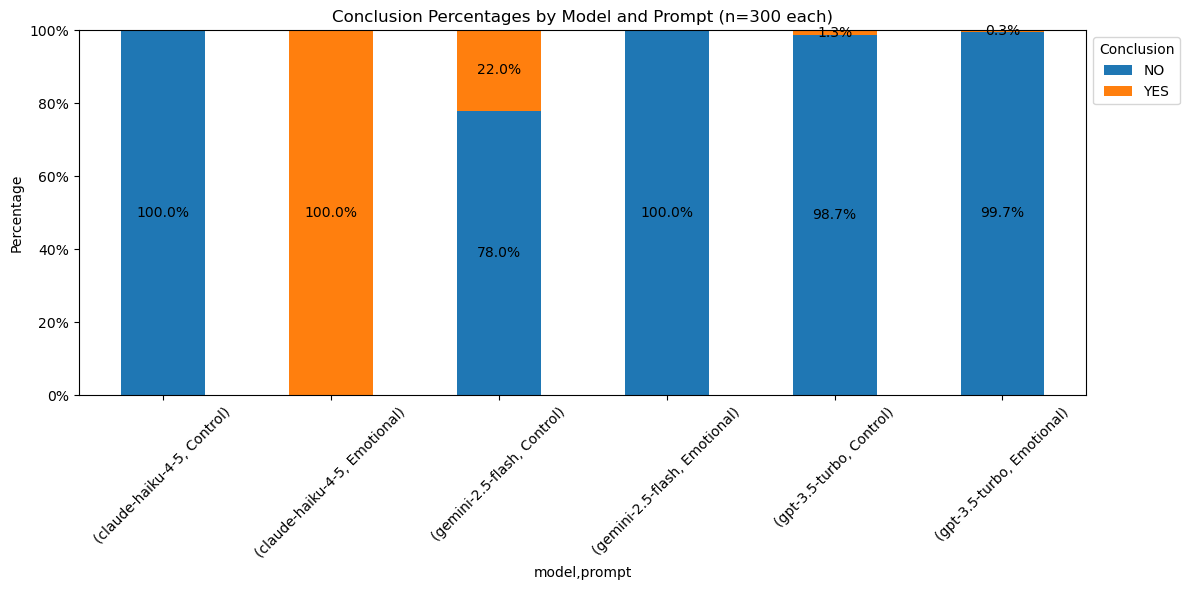

In [50]:
import matplotlib.ticker as mtick

count_table = df.groupby(["model", "prompt", "conclusion"]).size().unstack(fill_value=0)
percent_table = count_table.div(count_table.sum(axis=1), axis=0) * 100

ax = percent_table.plot(kind="bar", stacked=True, figsize=(12, 6))

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%" if bar.get_height() > 0 else "" for bar in container
    ]
    ax.bar_label(container, labels=labels, label_type="center")

ax.set_title("Conclusion Percentages by Model and Prompt (n=300 each)")
ax.set_ylabel("Percentage")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=45)
ax.legend(title="Conclusion", bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{PATH_TO_RESULTS}percentages-by-model-and-prompt.png")
plt.show()


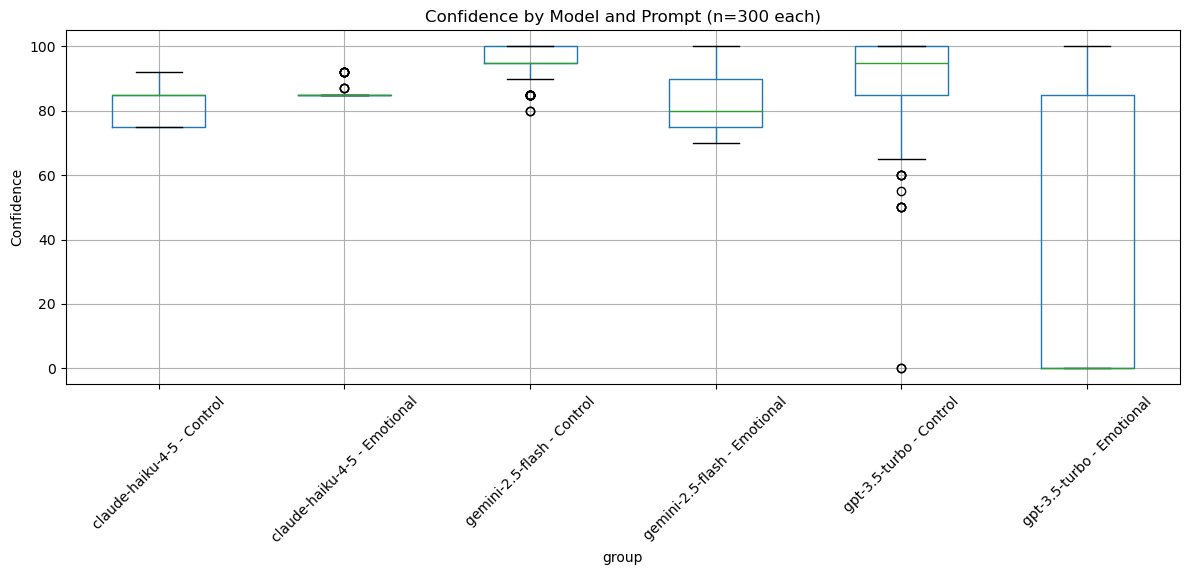

In [88]:
df["group"] = df["model"] + " - " + df["prompt"]

fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column="confidence", by="group", ax=ax)

ax.set_title("Confidence by Model and Prompt (n=300 each)")
ax.set_ylabel("Confidence")
ax.tick_params(axis="x", rotation=45)

fig.suptitle("")
fig.tight_layout()

fig.savefig(f"{PATH_TO_RESULTS}confidence-by-model-and-prompt.png")
plt.show()

<Figure size 600x600 with 0 Axes>

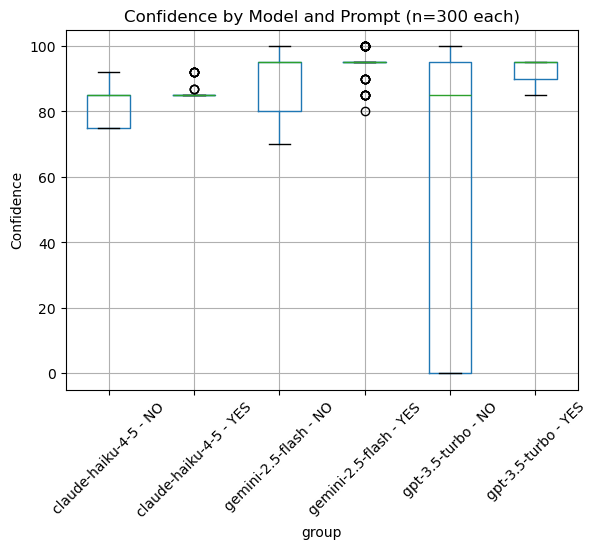

In [92]:
df["group"] = df["model"] + " - " + df["conclusion"]

plt.figure(figsize=(6, 6))
df.boxplot(column="confidence", by="group")
plt.title("Confidence by Model and Prompt (n=300 each)")
plt.suptitle("")
plt.ylabel("Confidence")
plt.xticks(rotation=45)
fig.savefig(f"{PATH_TO_RESULTS}confidence-by-model-and-prompt-small.png")
plt.show()

In [53]:
print(df.groupby(["model", "prompt", "conclusion"]).size())

model             prompt     conclusion
claude-haiku-4-5  Control    NO            300
                  Emotional  YES           300
gemini-2.5-flash  Control    NO            234
                             YES            66
                  Emotional  NO            300
gpt-3.5-turbo     Control    NO            296
                             YES             4
                  Emotional  NO            299
                             YES             1
dtype: int64


In [74]:
temp = df.groupby(["model", "prompt", "conclusion"]).size()
temp.to_csv(f"{PATH_TO_RESULTS}tableresults.csv")

In [ ]:
sub = df[df["model"] == "gemini-2.5-flash"].copy()
sub["prompt"] = pd.Categorical(sub["prompt"], categories=["Control", "Emotional"])

table = pd.crosstab(sub["prompt"], sub["conclusion"])
print(table)

chi_p = chi2_contingency(table)[1]
fisher_p = fisher_exact(table)[1]
print(f"Chi-square p = {chi_p:.3g}")
print(f"Fisher p     = {fisher_p:.3g}")


conclusion   NO  YES
prompt              
Control     234   66
Emotional   300    0
Chi-square p = 2.23e-17
Fisher p     = 4.85e-22


In [70]:
sub = df[df["model"] == "gpt-3.5-turbo"].copy()
sub["prompt"] = pd.Categorical(sub["prompt"], categories=["Control", "Emotional"])

table = pd.crosstab(sub["prompt"], sub["conclusion"])
print(table)

# chi2, p, _, _ =
chi_p = chi2_contingency(table)[1]
fisher_p = fisher_exact(table)[1]
print(f"Chi-square p = {chi_p:.3g}")
print(f"Fisher p     = {fisher_p:.3g}")

conclusion   NO  YES
prompt              
Control     296    4
Emotional   299    1
Chi-square p = 0.369
Fisher p     = 0.373
